<a href="https://colab.research.google.com/github/sunithamalathi1016-dotcom/House-Price-Prediction/blob/main/creditcard_task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("CREDIT CARD FRAUD DETECTION")

CREDIT CARD FRAUD DETECTION


In [ ]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
# Load Dataset

data = pd.read_csv("creditcard.csv", on_bad_lines='skip')

print("Dataset Loaded Successfully")
data.head()

Dataset Loaded Successfully


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print("Shape of Dataset")
print(data.shape)

print("\nColumn Names")
print(data.columns)

print("\nDataset Information")
print(data.info())

print("\nSummary Statistics")
print(data.describe())

Shape of Dataset
(284807, 31)

Column Names
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-nul

In [ ]:
print(data.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


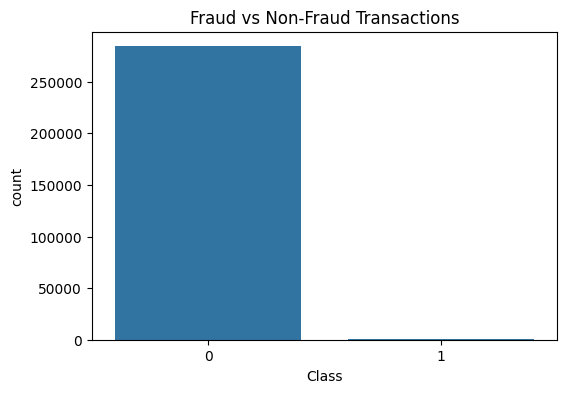

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=data)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()



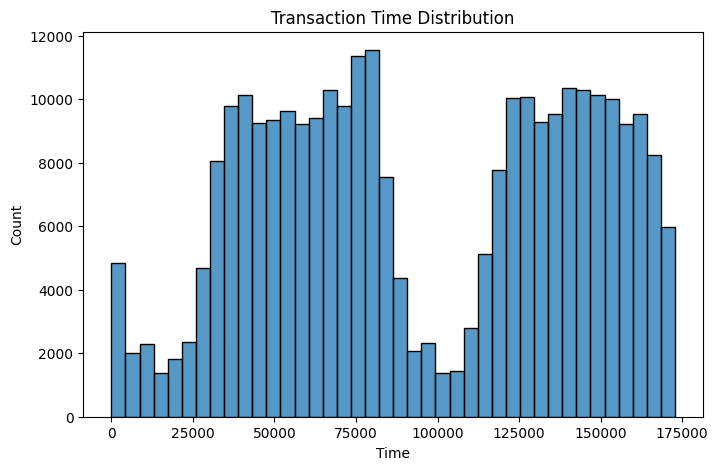

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data['Time'], bins=40)
plt.title("Transaction Time Distribution")
plt.show()

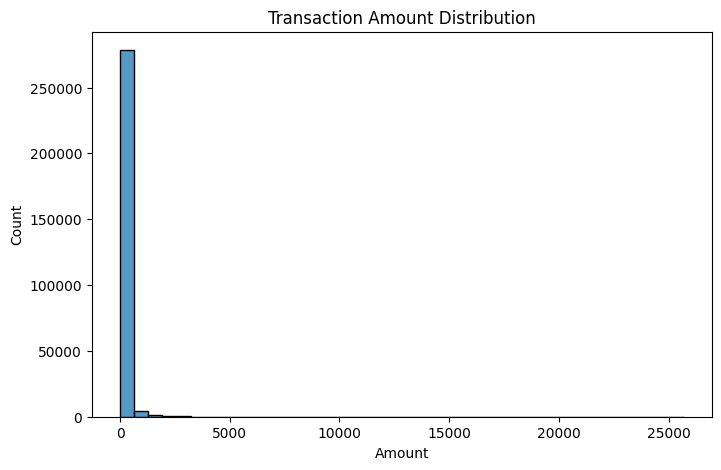

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data['Amount'], bins=40)
plt.title("Transaction Amount Distribution")
plt.show()


Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


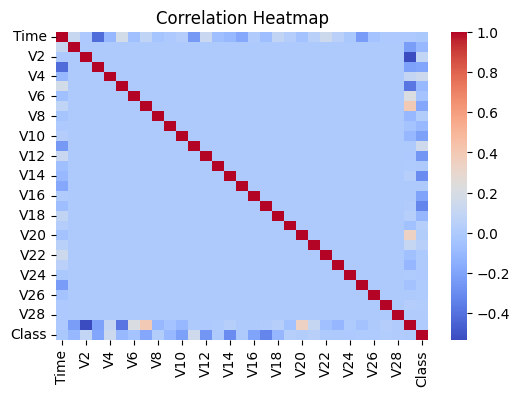

In [ ]:
print(data.dtypes)
import pandas as pd

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna()
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

corr = data.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X = data.drop("Class",axis=1)

y = data["Class"]

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


In [ ]:
# Logistic Regression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [ ]:
# Decision Tree

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [41]:
# Random Forest

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [42]:
# KNN

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

In [47]:
# SVM

svm = SVC()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

In [43]:
def evaluate_model(name, y_test, pred):

    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred, zero_division=0))
    print("Recall   :", recall_score(y_test, pred, zero_division=0))
    print("F1 Score :", f1_score(y_test, pred, zero_division=0))

    print("\nConfusion Matrix")

    print(confusion_matrix(y_test, pred))

    print("\n")

In [ ]:
evaluate_model("Logistic Regression", y_test, pred_lr)

evaluate_model("Decision Tree", y_test, pred_dt)

evaluate_model("Random Forest", y_test, pred_rf)

evaluate_model("KNN", y_test, pred_knn)

evaluate_model("Support Vector Machine", y_test, pred_svm)

Logistic Regression
Accuracy : 0.9991222218320986
Precision: 0.8636363636363636
Recall   : 0.5816326530612245
F1 Score : 0.6951219512195121

Confusion Matrix
[[56855     9]
 [   41    57]]


Decision Tree
Accuracy : 0.9990519995786665
Precision: 0.6964285714285714
Recall   : 0.7959183673469388
F1 Score : 0.7428571428571429

Confusion Matrix
[[56830    34]
 [   20    78]]


Random Forest
Accuracy : 0.9995611109160493
Precision: 0.974025974025974
Recall   : 0.7653061224489796
F1 Score : 0.8571428571428571

Confusion Matrix
[[56862     2]
 [   23    75]]


KNN
Accuracy : 0.9995259997893332
Precision: 0.9382716049382716
Recall   : 0.7755102040816326
F1 Score : 0.8491620111731844

Confusion Matrix
[[56859     5]
 [   22    76]]


Support Vector Machine
Accuracy : 0.9993153330290369
Precision: 0.9682539682539683
Recall   : 0.6224489795918368
F1 Score : 0.7577639751552795

Confusion Matrix
[[56862     2]
 [   37    61]]




In [46]:
pickle.dump(lr, open("logistic_regression.pkl", "wb"))

pickle.dump(dt, open("decision_tree.pkl", "wb"))

pickle.dump(rf, open("random_forest.pkl", "wb"))

pickle.dump(knn, open("knn.pkl", "wb"))

pickle.dump(svm, open("svm.pkl", "wb"))

print("All Models Saved Successfully!")

All Models Saved Successfully!


In [45]:
print(os.listdir())

['.config', 'svm.pkl', '.ipynb_checkpoints', 'decision_tree.pkl', 'random_forest.pkl', 'logistic_regression.pkl', 'creditcard.csv', 'knn.pkl', 'sample_data']


In [44]:
print("""
Project Summary

The Credit Card Fraud Detection Using Machine Learning project was developed to
identify fraudulent credit card transactions by analyzing transaction patterns
and characteristics. The dataset was explored, preprocessed, and visualized to
gain meaningful insights before training the models. Five machine learning
classification algorithms—Logistic Regression, Decision Tree, Random Forest,
K-Nearest Neighbors (KNN), and Support Vector Machine (SVM)—were implemented
and evaluated using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix.
The comparative analysis helped identify the best-performing model, which was
then saved as a Pickle (.pkl) file for future use. This project provided
practical experience in the complete machine learning pipeline, including data
preprocessing, exploratory data analysis, model development, performance
evaluation, and model persistence for real-world fraud detection applications.
""")


Project Summary

The Credit Card Fraud Detection Using Machine Learning project was developed to
identify fraudulent credit card transactions by analyzing transaction patterns
and characteristics. The dataset was explored, preprocessed, and visualized to
gain meaningful insights before training the models. Five machine learning
classification algorithms—Logistic Regression, Decision Tree, Random Forest,
K-Nearest Neighbors (KNN), and Support Vector Machine (SVM)—were implemented
and evaluated using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix.
The comparative analysis helped identify the best-performing model, which was
then saved as a Pickle (.pkl) file for future use. This project provided
practical experience in the complete machine learning pipeline, including data
preprocessing, exploratory data analysis, model development, performance
evaluation, and model persistence for real-world fraud detection applications.

